# 臺灣電網逐時綠度與企業 RE100 策略分析

環境與能源的資料科學

B11208018 李適軒

---

本報告回溯計算 2020–2024 年台灣電網的 hourly Carbon-Free Electricity (CFE) Score，
模擬 RE100 企業在不同採購策略下的碳排表現，並以機器學習模型分析天氣對電網「綠度」的驅動因子。
本研究作為 TransitionZero (2025) 前瞻模型的歷史對照基準線。

In [19]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 全域繪圖設定
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 12,
    "font.family": "Product Sans",
    "axes.grid": True,
    "grid.alpha": 0.3,
})
DPI = 300

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Introduction

### 研究問題與動機

隨著台灣推動 2050 淨零排放，越來越多跨國企業（如 TSMC、Apple 供應鏈）須達成 RE100 承諾。
傳統「年度綠電憑證」（RECs）只能宣稱年度 100% 再生能源，卻無法保證每小時皆有匹配的零碳電力。
Google 等企業已採用更嚴格的 **24/7 CFE（Carbon-Free Energy）Score** 方法，要求逐時匹配。

本報告提問：**台灣電網的 hourly CFE 實況為何？RE100 企業在不同採購策略下，24/7 CFE Score 落差有多大？**

### 與 TransitionZero (2025) 的關係

TransitionZero (2025) 以能源系統模型預測台灣 2030 年電網組成；本報告以台電實際發電資料建立 2020–2024 年歷史基準線，作為對照參考。

### CFE 定義與方法論

**Grid CFE %**：電網中來自零碳電源（太陽能、風力、水力、核能、地熱）的比例
**24/7 CFE Score**：企業每小時自 PPA 及電網獲得的零碳電力比例的全年平均值
計算詳見 Google (2022)《24/7 Carbon-Free Energy: Methodologies and Metrics》

## 2. Data Loading & Preprocessing

In [20]:
import pyarrow.parquet as pq

table = pq.read_table(DATA_DIR / "power_gen_by_category.parquet")
df = table.to_pandas(ignore_metadata=True)
df.to_csv(DATA_DIR / "power_gen_by_category.csv", index=False)

power_raw = pd.read_csv(DATA_DIR / "power_gen_by_category.csv")
power_raw['datetime'] = pd.to_datetime(power_raw['datetime'])
power_raw = power_raw.set_index('datetime').sort_index()
power_raw.head()

,EnergyStorageDischarge,EnergyStorageSystem,EnergyStorageSystemLoad,OtherRenewableEnergy,coal,cogen,diesel,geothermal,hydro,ippcoal,ipplng,lng,nuclear,oil,others,pumpinggen,pumpingload,solar,solarU,wind
datetime,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0.0,0.0,0.0,0.0,6011.5,774.5,67.9,0.0,257.0,1721.3,1096.7,7030.6,3872.9,153.3,0.0,574.9,0.0,0.0,0.0,531.4
2020-01-01 00:10:00,0.0,0.0,0.0,0.0,5947.9,718.9,65.3,0.0,250.8,1696.6,1096.2,7015.5,3864.1,153.3,0.0,492.7,0.0,0.0,0.0,513.3
2020-01-01 00:20:00,0.0,0.0,0.0,0.0,5881.5,830.8,66.0,0.0,247.4,1657.3,1094.8,7167.4,3860.7,153.3,0.0,435.8,0.0,0.0,0.0,508.7
2020-01-01 00:30:00,0.0,0.0,0.0,0.0,5847.3,706.5,67.0,0.0,296.1,1627.0,861.9,7144.8,3880.8,152.7,0.0,500.1,0.0,0.0,0.0,503.7
2020-01-01 00:40:00,0.0,0.0,0.0,0.0,5784.6,717.8,67.5,0.0,268.7,1594.6,661.0,7370.8,3875.3,152.0,0.0,495.1,0.0,0.0,0.0,513.1


In [21]:
# 載入中央氣象署小時資料
weather_raw = pd.read_csv(DATA_DIR / "weather_data_2016_2025.csv", low_memory=False)
weather_raw['ObsTime'] = pd.to_datetime(weather_raw['ObsTime'])
weather_raw = weather_raw.set_index('ObsTime').sort_index()

# 只保留 2020–2024
weather_raw = weather_raw.loc['2020':'2024'].copy()

# 數值強制轉型（部分欄位可能含文字缺值代碼）
WEATHER_COLS = ['Temperature', 'WS', 'Precp', 'GloblRad']
for col in WEATHER_COLS:
    weather_raw[col] = pd.to_numeric(weather_raw[col], errors='coerce')

# 夜間 GloblRad 為 0（無日照），其餘用前向填補
weather_raw['GloblRad'] = weather_raw['GloblRad'].clip(lower=0).fillna(0)
weather_raw[['Temperature', 'WS', 'Precp']] = (
    weather_raw[['Temperature', 'WS', 'Precp']].ffill(limit=6)
)

print(f"Weather data shape: {weather_raw.shape}")
weather_raw[WEATHER_COLS].describe()

Weather data shape: (43848, 23)


,Temperature,WS,Precp,GloblRad
count,43848.000000,43848.000000,43848.000000,43848.000000
mean,23.963779,2.194718,-0.700187,0.559726
std,5.795911,1.522972,5.871530,0.905304
min,-99.500000,-99.500000,-999.500000,0.000000
25%,19.400000,1.200000,0.000000,0.000000
50%,24.300000,2.100000,0.000000,0.010000
75%,28.400000,3.000000,0.000000,0.770000
max,39.000000,11.100000,90.000000,4.300000


In [22]:
# 10分鐘 → hourly（MW 為平均功率，取 mean）
power_hourly = power_raw.resample('h').mean()

# 氣象資料已是 hourly，重新採樣對齊（取 mean 防止重複時間戳）
weather_hourly = weather_raw[WEATHER_COLS].resample('h').mean()

print(f"Hourly power: {power_hourly.shape}")
print(f"Hourly weather: {weather_hourly.shape}")

Hourly power: (43848, 20)
Hourly weather: (43847, 4)


In [23]:
# 資料品質檢查：缺值百分比
print("=== Power missing values (%) ===")
mv_power = (power_hourly.isna().sum() / len(power_hourly) * 100).round(2)
print(mv_power[mv_power > 0].to_string() if mv_power[mv_power > 0].any() else "No missing values")

print("\n=== Weather missing values (%) ===")
mv_wx = (weather_hourly.isna().sum() / len(weather_hourly) * 100).round(2)
print(mv_wx)

# 最終缺值填補（用前向填補，上限 3 小時）
power_hourly = power_hourly.ffill(limit=3).fillna(0)
weather_hourly = weather_hourly.ffill(limit=3).fillna(0)

=== Power missing values (%) ===
EnergyStorageDischarge     10.26
EnergyStorageSystem        10.26
EnergyStorageSystemLoad    10.26
OtherRenewableEnergy       10.26
coal                       10.26
cogen                      10.26
diesel                     10.26
geothermal                 10.26
hydro                      10.26
ippcoal                    10.26
ipplng                     10.26
lng                        10.26
nuclear                    10.26
oil                        10.26
others                     10.26
pumpinggen                 10.26
pumpingload                10.26
solar                      10.26
solarU                     10.26
wind                       10.26

=== Weather missing values (%) ===
Temperature    4.16
WS             4.16
Precp          4.16
GloblRad       4.16
dtype: float64


In [24]:
# 由 emissions.csv 讀取燃料別排放係數（推估電力係數，tCO2/MWh）
emissions_raw = pd.read_csv(DATA_DIR / "emissions.csv")
emissions_raw.columns = ['year', 'fuel_cn', 'emissions_wan_ton', 'gen_yi_kwh', 'ef_tco2_mwh']

print("各年度燃料排放係數 (tCO2/MWh):")
print(emissions_raw.pivot(index='year', columns='fuel_cn', values='ef_tco2_mwh').round(4).to_string())

# 2020–2024 平均係數（用於後續計算）
ef_avg = emissions_raw.groupby('fuel_cn')['ef_tco2_mwh'].mean()
EF_COAL = round(ef_avg['燃煤'], 4)
EF_GAS  = round(ef_avg['燃氣'], 4)
EF_OIL  = round(ef_avg['燃油'], 4)
print(f"\n平均係數：燃煤: {EF_COAL}, 燃氣: {EF_GAS}, 燃油: {EF_OIL}")

各年度燃料排放係數 (tCO2/MWh):
fuel_cn      燃氣      燃油      燃煤
year                           
2020     0.3170  0.7963  0.6817
2021     0.3068  0.8000  0.7089
2022     0.3073  0.7960  0.7052
2023     0.2964  0.8080  0.6973
2024     0.2867  0.8070  0.6896

平均係數：燃煤: 0.6965, 燃氣: 0.3028, 燃油: 0.8015


In [35]:
# 燃料分類（依 CLAUDE.md 規格）
CFE_COLS = ['nuclear', 'solar', 'solarU', 'wind', 'hydro', 'geothermal', 'OtherRenewableEnergy']

# 排放係數 (tCO2/MWh = kgCO2/kWh)，來源：IPCC 2006（已含發電效率換算）
EMISSION_FACTORS = {
    'coal':    0.95,   # 燃煤（超臨界效率 ~38%）
    'ippcoal': 0.95,
    'lng':     0.37,   # 燃氣複循環 CCGT（效率 ~55%）
    'ipplng':  0.37,
    'oil':     0.65,   # 燃油
    'diesel':  0.65,
}
NON_CFE_COLS = list(EMISSION_FACTORS.keys())

# 燃料別不明但確實送入電網：不計入 CFE，但計入分母
DENOMINATOR_EXTRA = ['cogen', 'pumpinggen', 'EnergyStorageDischarge', 'others']

# 計算各類別發電量
power_hourly['cfe_gen']     = power_hourly[CFE_COLS].sum(axis=1)
power_hourly['non_cfe_gen'] = power_hourly[NON_CFE_COLS].sum(axis=1)
power_hourly['extra_gen']   = power_hourly[DENOMINATOR_EXTRA].sum(axis=1)
power_hourly['total_gen']   = (power_hourly['cfe_gen']
                                + power_hourly['non_cfe_gen']
                                + power_hourly['extra_gen'])

# 排除 total_gen ≈ 0 的異常行
power_hourly = power_hourly[power_hourly['total_gen'] > 0]
print(f"Valid hourly rows: {len(power_hourly)}")
print(f"Extra gen share (mean): {(power_hourly['extra_gen']/power_hourly['total_gen']).mean():.1%}")

Valid hourly rows: 39409
Extra gen share (mean): 3.0%


In [26]:
# 合併電力與氣象 DataFrame
df = power_hourly.join(weather_hourly, how='left')
df = df[df['total_gen'] > 0].copy()

# 時間特徵
df['hour']        = df.index.hour
df['month']       = df.index.month
df['year']        = df.index.year
df['day_of_week'] = df.index.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

print(f"Merged DataFrame: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
df[['cfe_gen', 'non_cfe_gen', 'total_gen', 'Temperature', 'WS', 'GloblRad']].head()

Merged DataFrame: (39409, 33)
Date range: 2020-01-01 00:00:00 → 2024-12-31 23:00:00


,cfe_gen,non_cfe_gen,total_gen,Temperature,WS,GloblRad
datetime,,,,,,
2020-01-01 00:00:00,4653.050000,15826.066667,21755.283333,NaN,NaN,NaN
2020-01-01 01:00:00,4620.933333,15515.616667,21355.050000,14.8,3.6,0.0
2020-01-01 02:00:00,4659.100000,15592.650000,21017.000000,14.8,3.3,0.0
2020-01-01 03:00:00,4598.133333,15425.916667,20771.883333,14.7,3.1,0.0
2020-01-01 04:00:00,4527.733333,15289.183333,20560.166667,14.5,4.3,0.0


## 3. 臺灣電網 CFE % 分析

計算每小時電網中來自零碳電源（太陽能、風力、水力、核能、地熱、其他再生能源）的比例，
並以 heatmap 呈現一天 24 小時 × 12 個月的分布規律。

In [27]:
# 計算每小時 Grid CFE %（0–1 fraction，保留小數以利後續計算）
df['grid_cfe_pct'] = (df['cfe_gen'] / df['total_gen']).clip(0, 1)

# 年度平均摘要
annual_cfe = df.groupby('year')['grid_cfe_pct'].agg(['mean', 'std', 'min', 'max']) * 100
annual_cfe.columns = ['Mean CFE%', 'Std', 'Min', 'Max']
print("=== Annual Grid CFE % Summary ===")
print(annual_cfe.round(2).to_string())

=== Annual Grid CFE % Summary ===
      Mean CFE%   Std   Min     Max
year                               
2020      17.00  3.44  8.54   30.67
2021      16.41  4.43  7.03   36.03
2022      16.56  4.99  8.08   34.57
2023      16.18  7.28  4.25  100.00
2024      16.48  8.61  1.54  100.00


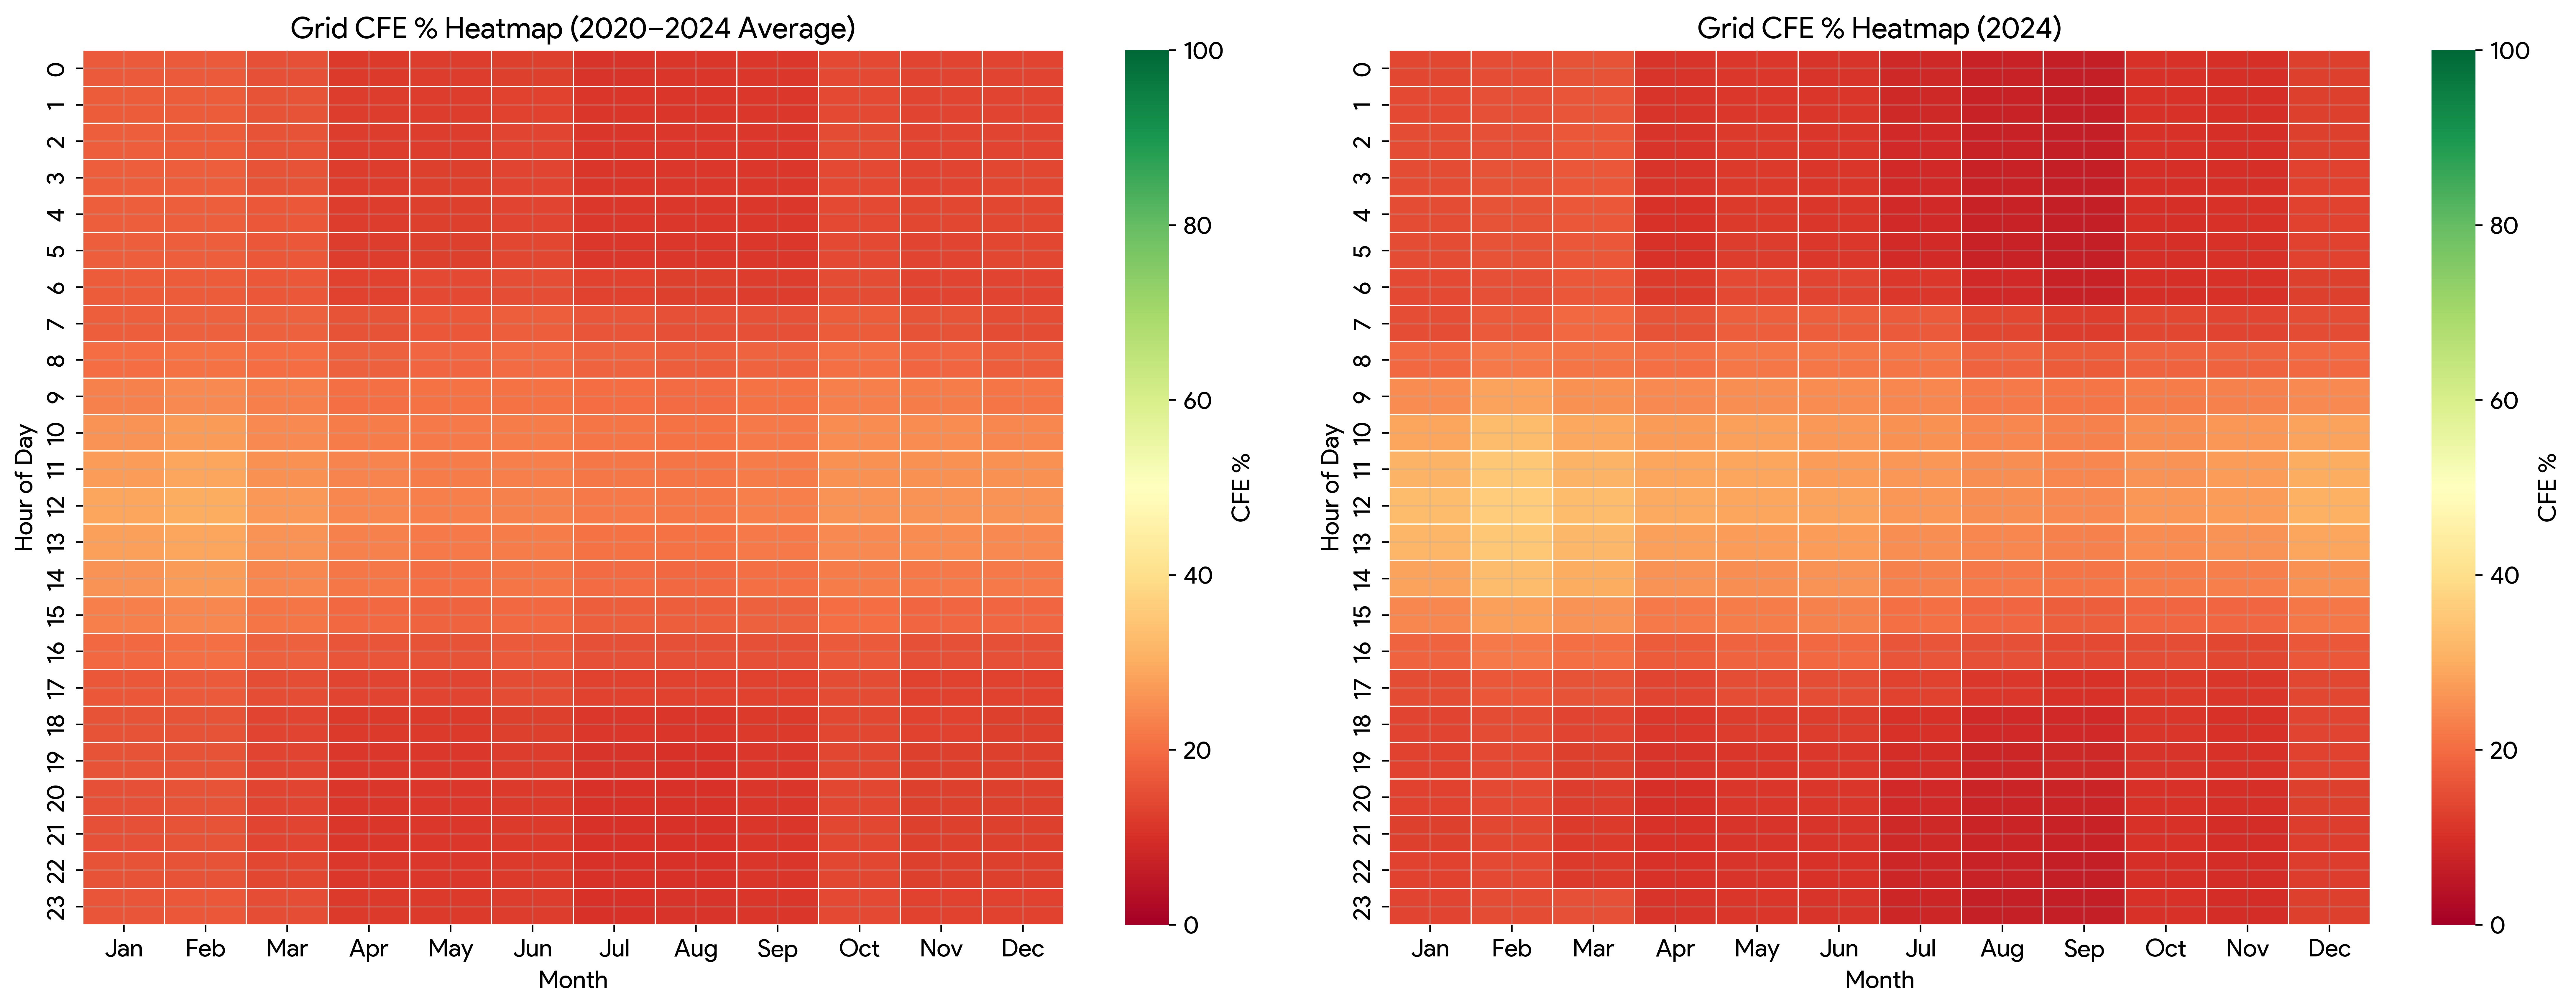

In [28]:
# Grid CFE % Heatmap：24h × 12month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=500)

# 5年平均（×100 for display）
pivot_all = df.groupby(['hour', 'month'])['grid_cfe_pct'].mean().unstack() * 100
sns.heatmap(pivot_all, ax=axes[0], cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.3, xticklabels=month_labels, cbar_kws={'label': 'CFE %'})
axes[0].set_title('Grid CFE % Heatmap (2020–2024 Average)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Hour of Day')

# 2024（最新一年）
pivot_2024 = df[df['year'] == 2024].groupby(['hour', 'month'])['grid_cfe_pct'].mean().unstack() * 100
pivot_2024 = pivot_2024.reindex(columns=range(1, 13))
sns.heatmap(pivot_2024, ax=axes[1], cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.3, xticklabels=month_labels, cbar_kws={'label': 'CFE %'})
axes[1].set_title('Grid CFE % Heatmap (2024)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Hour of Day')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cfe_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()

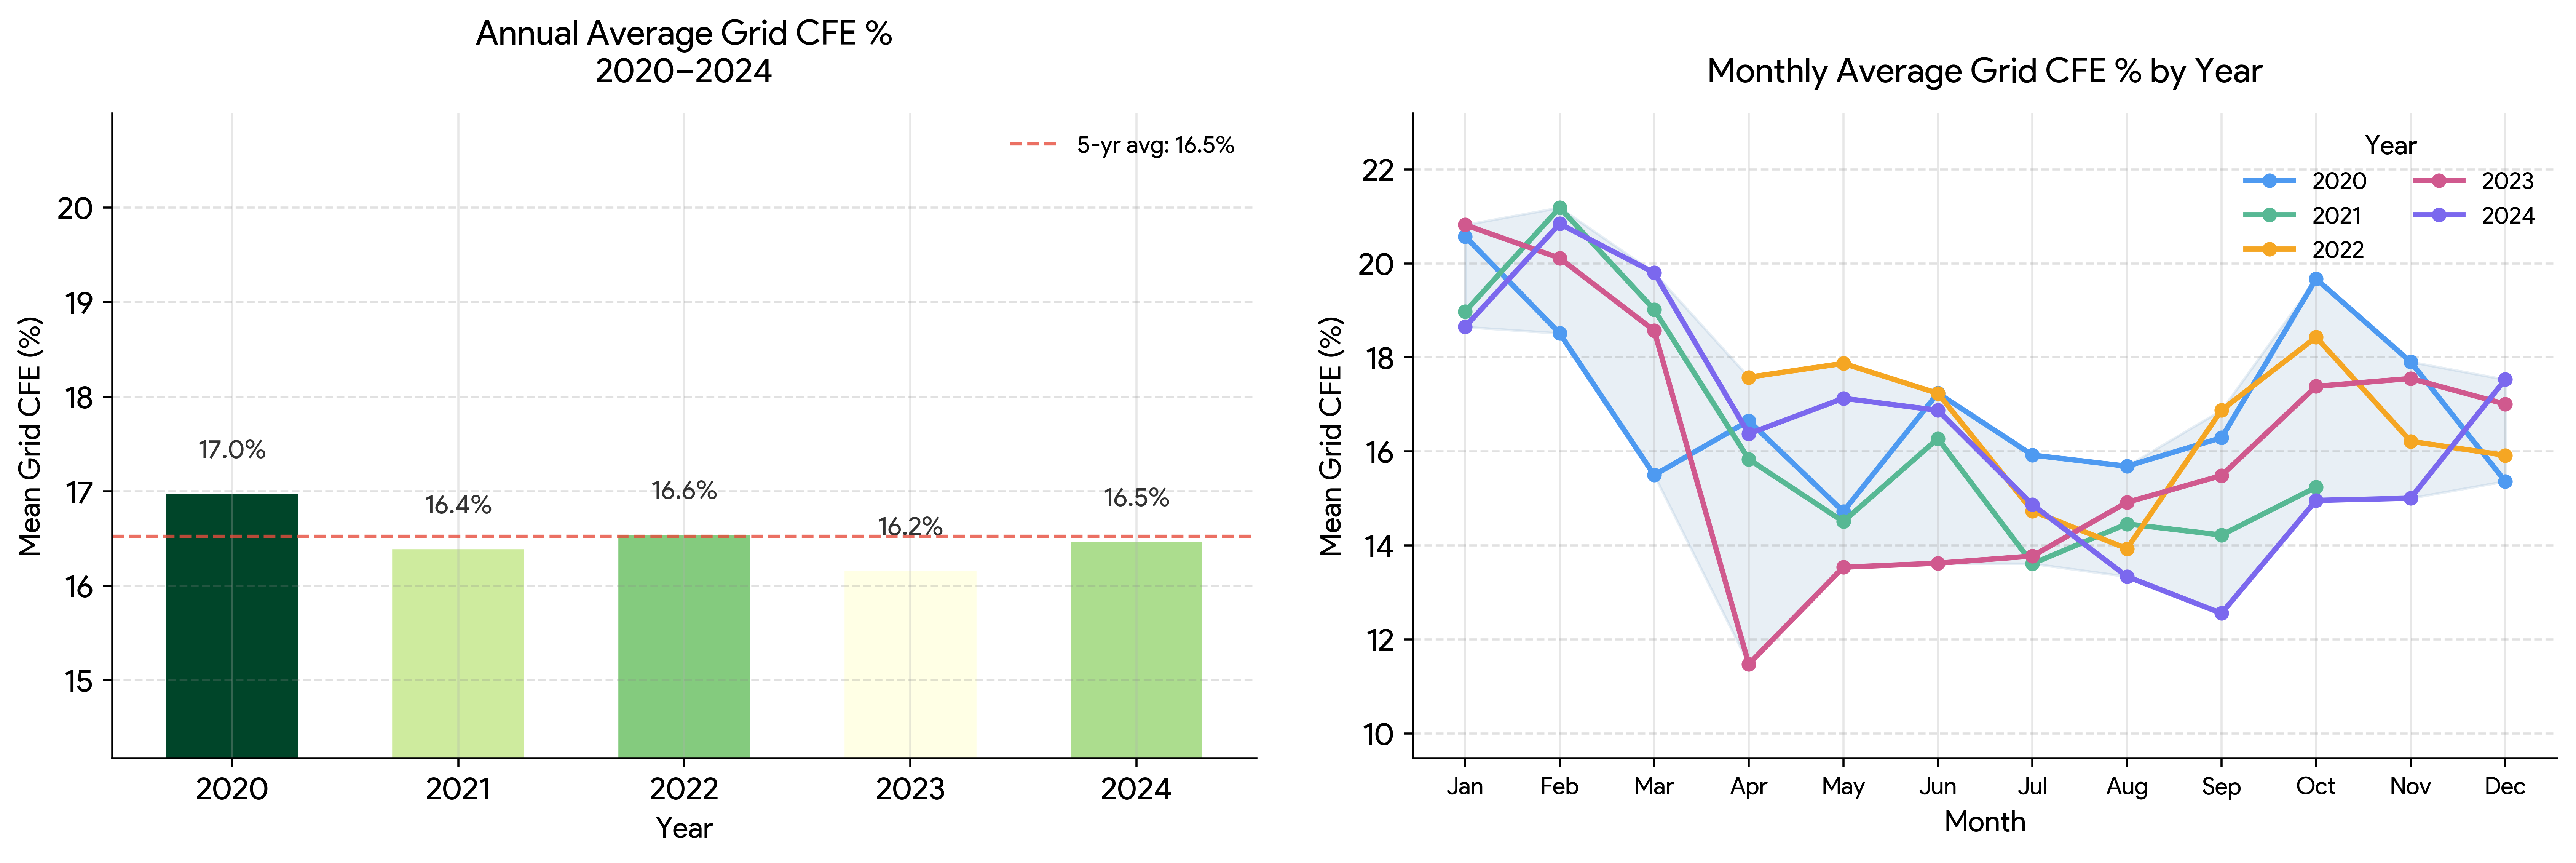

In [29]:
YEAR_COLORS = ['#4e9af1', '#57b894', '#f5a623', '#d0598e', '#7b68ee']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=500)
fig.patch.set_facecolor('white')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linestyle='--', color='#888')

# --- LEFT: Annual bar, colored by value ---
annual_mean = df.groupby('year')['grid_cfe_pct'].mean() * 100
y_pad = 2
norm = plt.Normalize(annual_mean.min(), annual_mean.max())
bar_colors = [plt.cm.YlGn(norm(v)) for v in annual_mean.values]

bars = axes[0].bar(annual_mean.index, annual_mean.values,
                   color=bar_colors, edgecolor='white',
                   linewidth=1.5, width=0.6)

axes[0].axhline(annual_mean.mean(), color='#e74c3c', linestyle='--',
                linewidth=1.2, alpha=0.8, label=f'5-yr avg: {annual_mean.mean():.1f}%')
axes[0].set_ylim(annual_mean.min() - y_pad, annual_mean.max() + y_pad + 2)
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Mean Grid CFE (%)', fontsize=11)
axes[0].set_title('Annual Average Grid CFE %\n2020–2024',
                  fontsize=13, pad=12)
axes[0].legend(frameon=False, fontsize=9)

for bar, val in zip(bars, annual_mean.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color='#333')

# --- RIGHT: Monthly lines + shaded range ---
monthly = df.groupby(['year', 'month'])['grid_cfe_pct'].mean().unstack(0) * 100
all_vals = monthly.values
y_min = max(0, np.nanmin(all_vals) - 2)
y_max = np.nanmax(all_vals) + 2

axes[1].fill_between(monthly.index,
                     monthly.min(axis=1), monthly.max(axis=1),
                     alpha=0.12, color='steelblue')

for i, yr in enumerate(monthly.columns):
    axes[1].plot(monthly.index, monthly[yr],
                 marker='o', markersize=4.5, linewidth=2,
                 color=YEAR_COLORS[i], label=str(yr), zorder=3)

axes[1].set_ylim(y_min, y_max)
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Mean Grid CFE (%)', fontsize=11)
axes[1].set_title('Monthly Average Grid CFE % by Year',
                  fontsize=13, pad=12)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=9)
axes[1].legend(title='Year', frameon=False, fontsize=9,
               title_fontsize=10, ncol=2)

plt.tight_layout(pad=2)
plt.savefig(OUTPUT_DIR / 'cfe_annual_monthly.png', dpi=DPI, bbox_inches='tight')
plt.show()

## 4. 每小時電網排放強度推估

依燃料別排放係數計算每小時電網排放強度（kgCO₂/kWh），
並與環境部每年公告的電力排放係數作比較。

In [ ]:
# 計算每小時排放強度
emission_num = pd.Series(0.0, index=df.index)
for fuel, ef in EMISSION_FACTORS.items():
    emission_num += df[fuel] * ef

df['emission_intensity'] = (emission_num / df['total_gen'] ).clip(lower=0)  # kgCO2/kWh

annual_ei = df.groupby('year')['emission_intensity'].mean().round(4)
annual_ei

year
2020    0.5077
2021    0.5089
2022    0.5036
2023    0.5006
2024    0.4928
Name: emission_intensity, dtype: float64

In [55]:
# 以 emissions.csv 回推係數計算排放強度（對照用）
EMISSION_FACTORS_DERIVED = {
    'coal':    EF_COAL,
    'ippcoal': EF_COAL,
    'lng':     EF_GAS,
    'ipplng':  EF_GAS,
    'oil':     EF_OIL,
    'diesel':  EF_OIL,
}

emission_num_derived = pd.Series(0.0, index=df.index)
for fuel, ef in EMISSION_FACTORS_DERIVED.items():
    emission_num_derived += df[fuel] * ef

annual_ei_derived = (emission_num_derived / df['total_gen']).clip(lower=0).groupby(df['year']).mean().round(4)
annual_ei_derived

year
2020    0.3889
2021    0.3904
2022    0.3866
2023    0.3861
2024    0.3831
dtype: float64

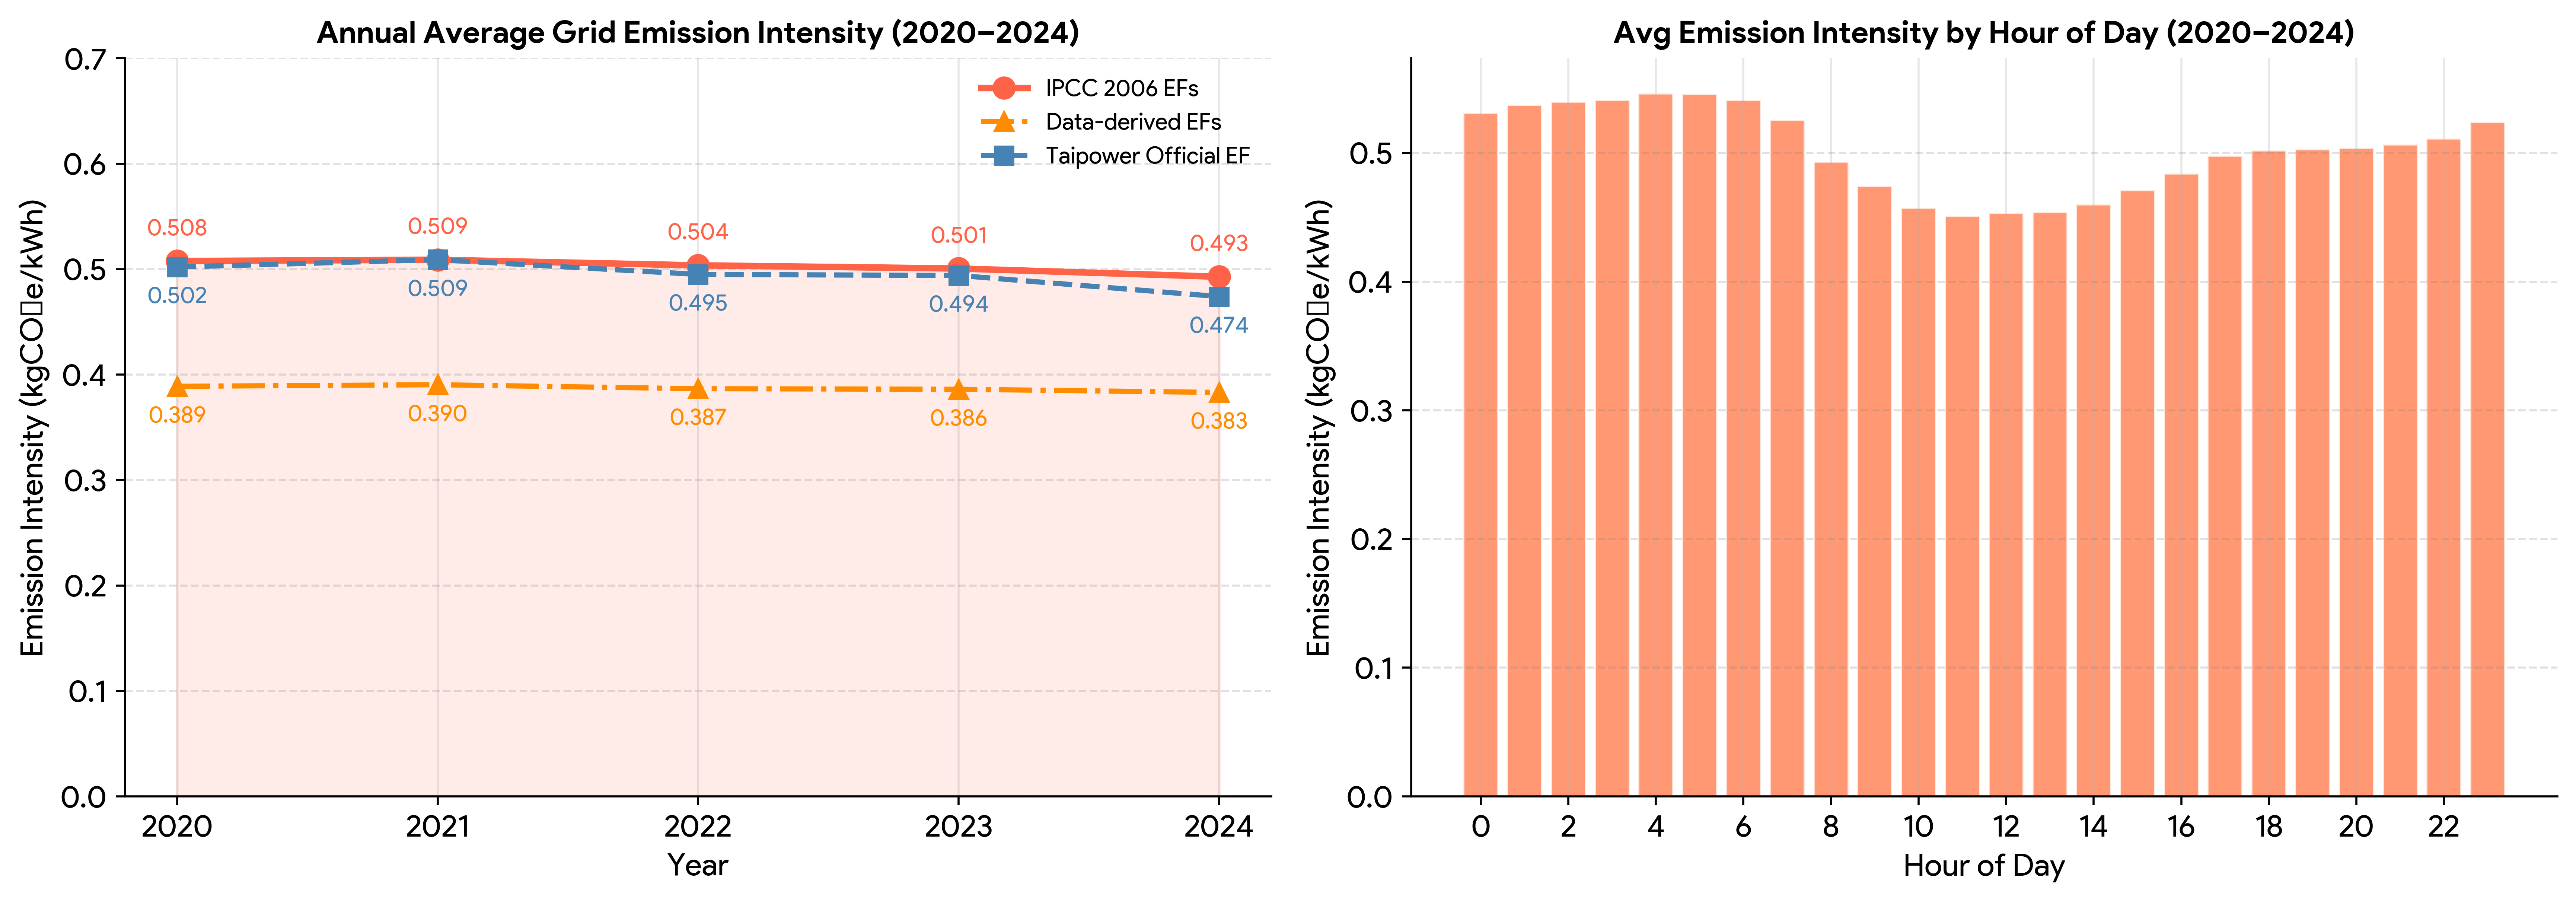

In [57]:
# 修正 year 為 int（在計算 annual_ei 之前）
df['year'] = df['year'].astype(int)
annual_ei = df.groupby('year')['emission_intensity'].mean().round(4)

# 台電公告電力係數 (kgCO2e/kWh)
taipower_ef = {2020: 0.502, 2021: 0.509, 2022: 0.495, 2023: 0.494, 2024: 0.474}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=500)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linestyle='--', color='#888')

# --- LEFT ---
axes[0].plot(annual_ei.index, annual_ei.values,
             marker='o', linewidth=2.5, color='tomato',
             markersize=8, label='IPCC 2006 EFs', zorder=3)
axes[0].fill_between(annual_ei.index, annual_ei.values, alpha=0.12, color='tomato')

axes[0].plot(annual_ei_derived.index, annual_ei_derived.values,
             marker='^', linewidth=2, linestyle='-.', color='darkorange',
             markersize=7, label='Data-derived EFs', zorder=3)

tp_years = list(taipower_ef.keys())
tp_vals  = list(taipower_ef.values())
axes[0].plot(tp_years, tp_vals,
             marker='s', linewidth=2, linestyle='--',
             color='steelblue', markersize=7,
             label='Taipower Official EF', zorder=3)

for x, y in zip(annual_ei.index, annual_ei.values):
    axes[0].annotate(f'{y:.3f}', (x, y),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=9, color='tomato')
for x, y in zip(annual_ei_derived.index, annual_ei_derived.values):
    axes[0].annotate(f'{y:.3f}', (x, y),
                     textcoords='offset points', xytext=(0, -14),
                     ha='center', fontsize=9, color='darkorange')
for x, y in zip(tp_years, tp_vals):
    axes[0].annotate(f'{y:.3f}', (x, y),
                     textcoords='offset points', xytext=(0, -14),
                     ha='center', fontsize=9, color='steelblue')

axes[0].set_xlabel('Year')
axes[0].set_ylabel('Emission Intensity (kgCO₂e/kWh)')
axes[0].set_title('Annual Average Grid Emission Intensity (2020–2024)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 0.7)
axes[0].set_xticks(sorted(set(list(annual_ei.index) + tp_years)))
axes[0].legend(frameon=False, fontsize=9, loc='upper right')

# --- RIGHT ---
hourly_ei = df.groupby('hour')['emission_intensity'].mean()

axes[1].bar(hourly_ei.index, hourly_ei.values,
            color='coral', alpha=0.8, edgecolor='white', linewidth=0.8)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Emission Intensity (kgCO₂e/kWh)')
axes[1].set_title('Avg Emission Intensity by Hour of Day (2020–2024)',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'emission_intensity.png', dpi=DPI, bbox_inches='tight')
plt.show()

## 5. RE100 企業模擬

以 2022 年（資料完整代表年）模擬 4 種情境：
- **D1**：24/7 工廠（固定負載）
- **D2**：9–5 辦公（工作時段加權）
- **S1**：純太陽能 PPA
- **S2**：Solar 70% + Wind 30% PPA

依 Google 24/7 CFE 方法論計算每小時 CFE Score，並比較年度聲稱（100%）與實際 hourly 平均的落差。

In [58]:
# 建構 2 種 Demand Profile（以 2022 年為代表年）
SIM_YEAR = 2024
ANNUAL_TOTAL = 1e6  # MWh（正規化單位）

year_idx = df[df['year'] == SIM_YEAR].index

def build_demand_D1(index):
    # 24/7 工廠：固定負載
    return pd.Series(ANNUAL_TOTAL / len(index), index=index)

def build_demand_D2(index):
    # 9-5 辦公：工作日 8-18 時為 1.5 倍，其餘 0.5 倍，假日 0.3 倍
    base = ANNUAL_TOTAL / len(index)
    load = pd.Series(base * 0.5, index=index)  # 預設：非工作時段
    is_weekday = index.dayofweek < 5
    is_work_hour = (index.hour >= 8) & (index.hour < 18)
    load[is_weekday & is_work_hour] = base * 1.5
    load[~is_weekday] = base * 0.3
    return load / load.sum() * ANNUAL_TOTAL  # 正規化確保年度總量不變

demand_D1 = build_demand_D1(year_idx)
demand_D2 = build_demand_D2(year_idx)

print(f"D1 annual total: {demand_D1.sum():.0f} MWh  (mean/hr: {demand_D1.mean():.2f})")
print(f"D2 annual total: {demand_D2.sum():.0f} MWh  (peak/mean ratio: {demand_D2.max()/demand_D2.mean():.2f})")

D1 annual total: 1000000 MWh  (mean/hr: 113.86)
D2 annual total: 1000000 MWh  (peak/mean ratio: 2.02)


In [59]:
# 建構 2 種 PPA 策略（使用台電實際出力正規化後 scale）
df_yr = df[df['year'] == SIM_YEAR].copy()

# 太陽能 profile（solar + solarU）
solar_raw = df_yr['solar'] + df_yr['solarU']
solar_norm = solar_raw / solar_raw.sum()  # 正規化

# 風力 profile
wind_norm = df_yr['wind'] / df_yr['wind'].sum()

# S2 混合：70% solar + 30% wind，再次正規化
mixed_raw = 0.7 * solar_norm + 0.3 * wind_norm
mixed_norm = mixed_raw / mixed_raw.sum()

def scale_ppa(profile_norm, annual_load):
    return profile_norm * annual_load

scenarios = {
    'D1S1': {'demand': demand_D1, 'ppa': scale_ppa(solar_norm, ANNUAL_TOTAL)},
    'D1S2': {'demand': demand_D1, 'ppa': scale_ppa(mixed_norm, ANNUAL_TOTAL)},
    'D2S1': {'demand': demand_D2, 'ppa': scale_ppa(solar_norm, ANNUAL_TOTAL)},
    'D2S2': {'demand': demand_D2, 'ppa': scale_ppa(mixed_norm, ANNUAL_TOTAL)},
}
print("PPA scenarios configured:", list(scenarios.keys()))

PPA scenarios configured: ['D1S1', 'D1S2', 'D2S1', 'D2S2']


In [61]:
# 計算每種情境的 hourly CFE Score（Google 24/7 CFE 方法論）
grid_cfe = df_yr['grid_cfe_pct']
results = {}

for name, sc in scenarios.items():
    load = sc['demand'].values
    ppa  = sc['ppa'].values
    gcfe = grid_cfe.values

    contracted_cfe    = np.minimum(load, ppa)
    grid_import       = load - contracted_cfe
    consumed_grid_cfe = grid_import * gcfe
    hourly_score      = (contracted_cfe + consumed_grid_cfe) / load

    annual_score = hourly_score.mean()
    results[name] = {
        'hourly_scores': pd.Series(hourly_score, index=year_idx),
        'annual_score':  annual_score,
        'gap':           1.0 - annual_score,
    }
    print(f"{name}: Annual claim=100.0%, Hourly avg={annual_score:.1%}, Gap={1-annual_score:.1%}")

D1S1: Annual claim=100.0%, Hourly avg=48.1%, Gap=51.9%
D1S2: Annual claim=100.0%, Hourly avg=63.0%, Gap=37.0%
D2S1: Annual claim=100.0%, Hourly avg=47.2%, Gap=52.8%
D2S2: Annual claim=100.0%, Hourly avg=68.8%, Gap=31.2%


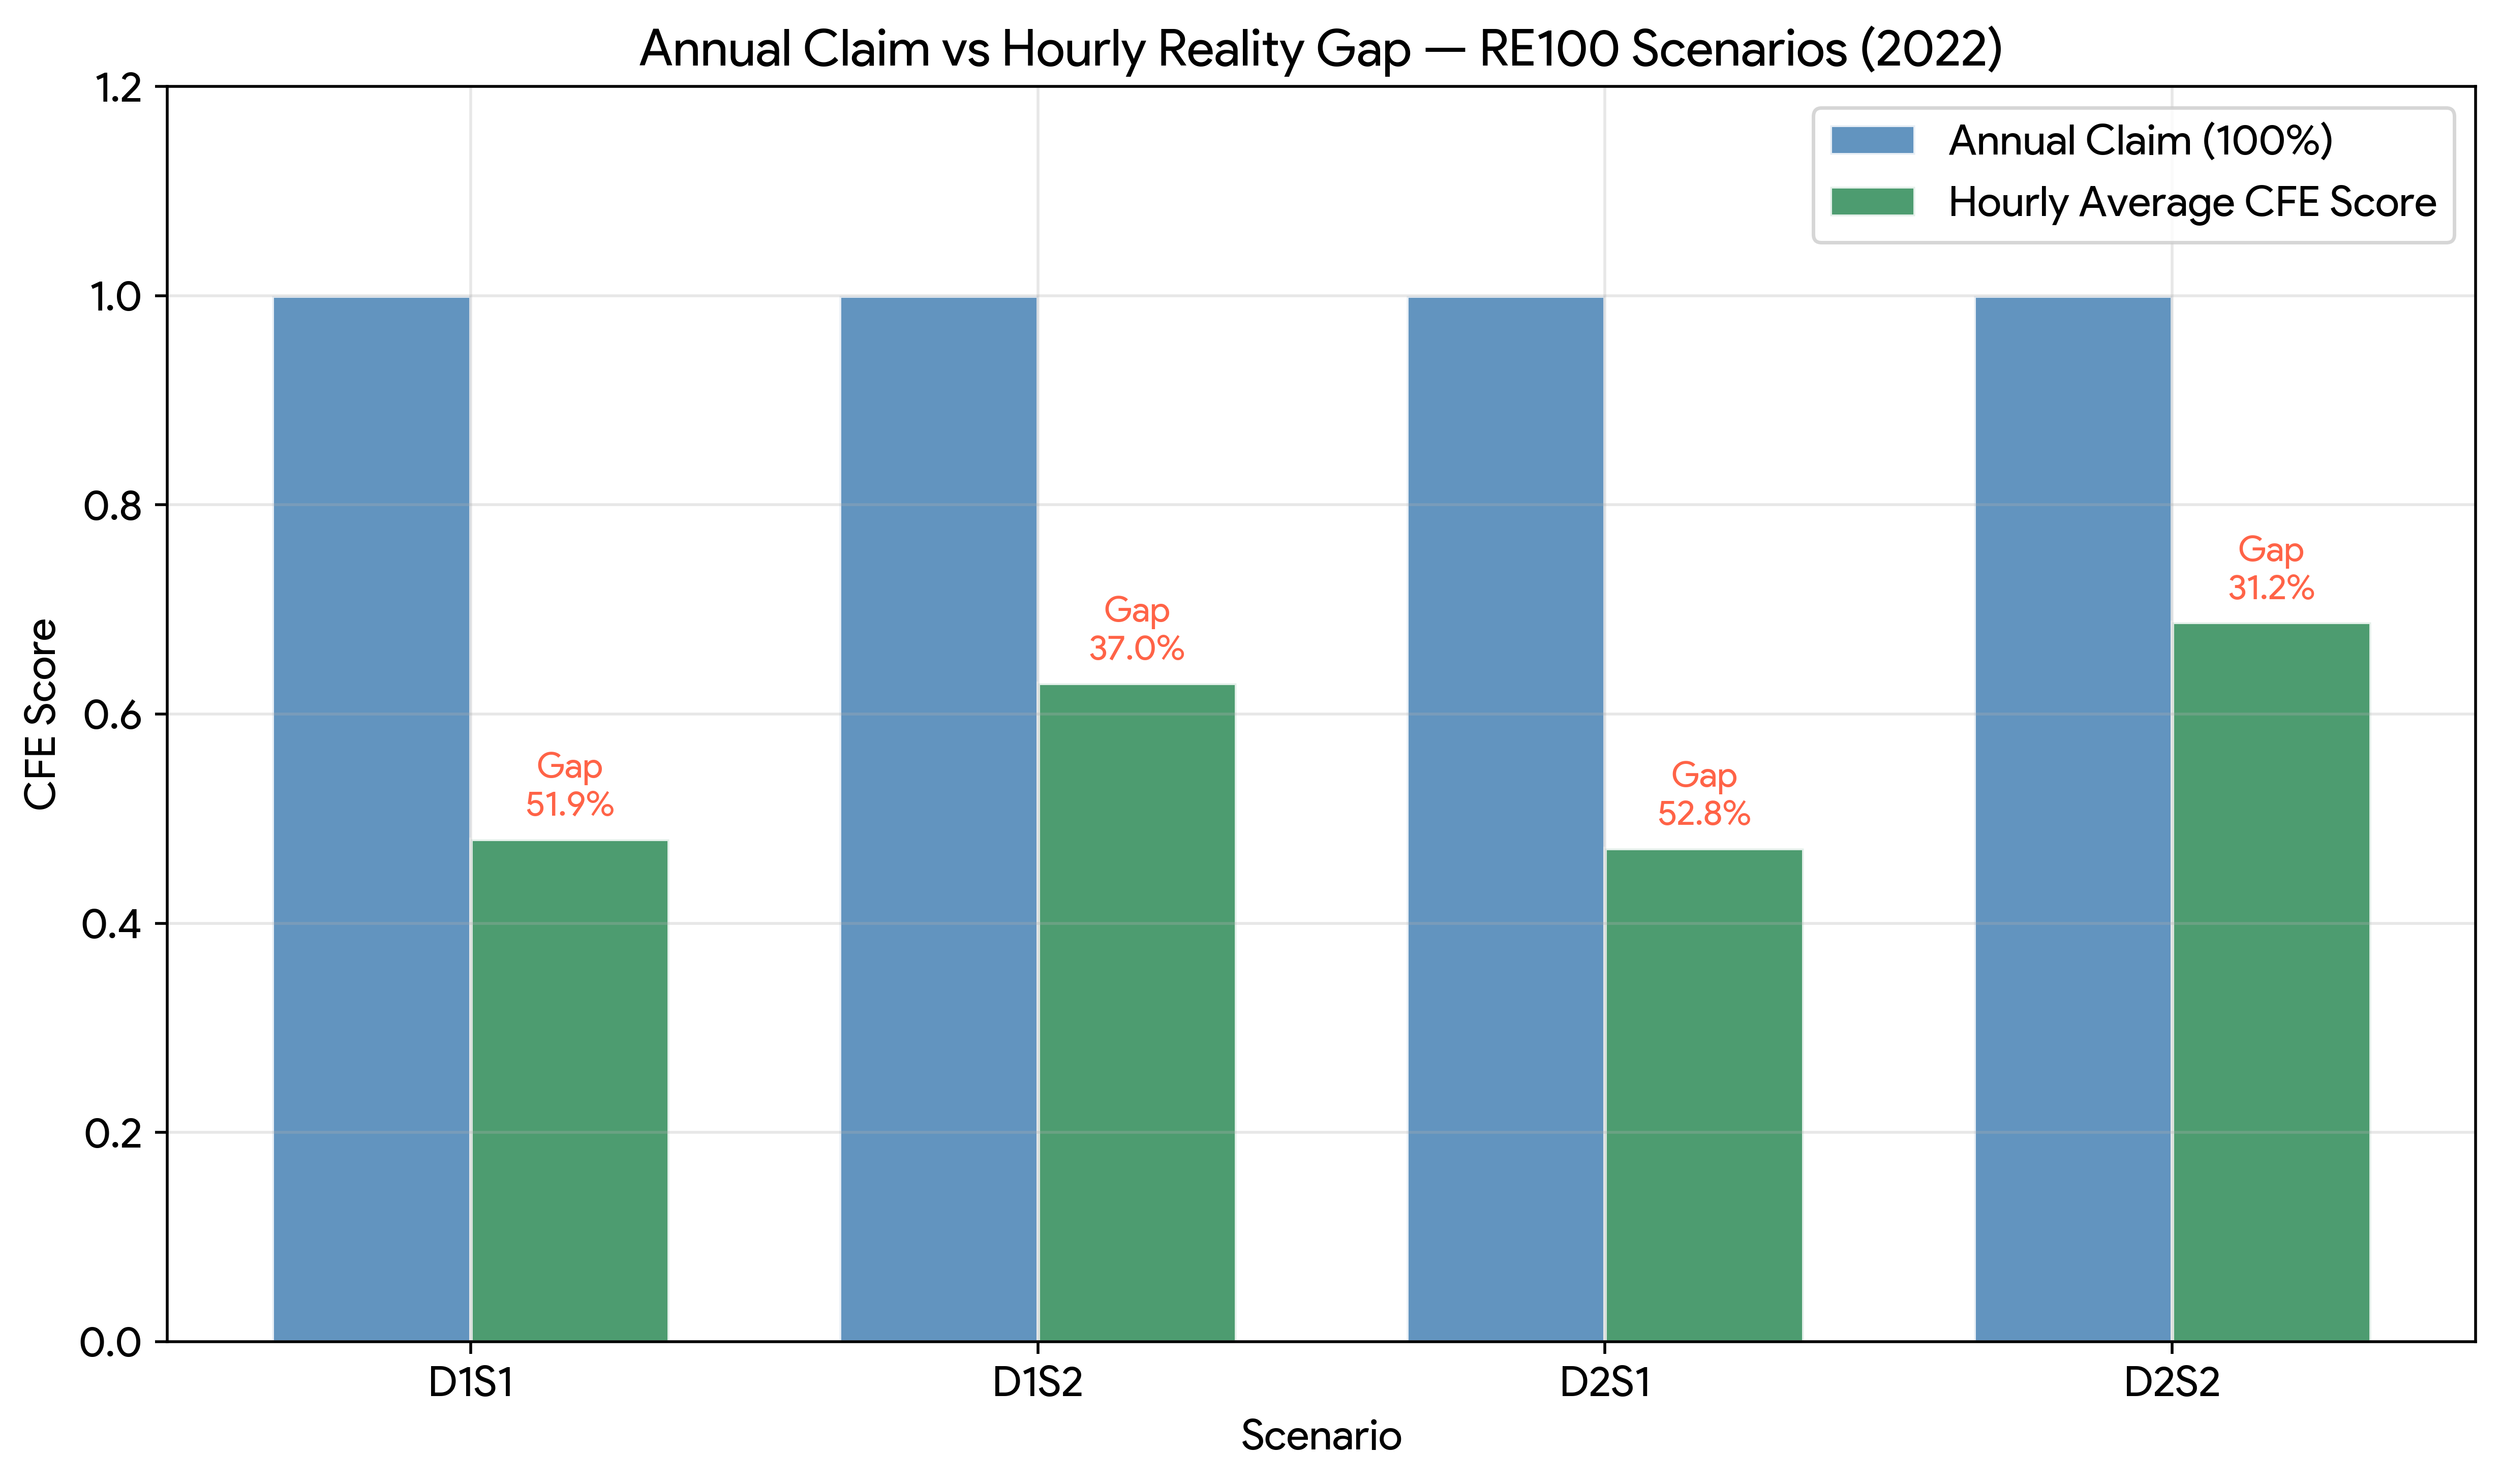

圖說：深藍色柱為年度宣稱（100%），綠色柱為實際 hourly 平均 CFE Score，紅字標示落差。可見純太陽能（S1）情境落差最大，加入風力（S2）可改善逐時匹配度。


In [63]:
# Annual vs Hourly Gap — grouped bar chart
labels = list(results.keys())
hourly_avgs = [results[k]['annual_score'] for k in labels]
gaps = [results[k]['gap'] for k in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6), dpi=500)
ax.bar(x - width/2, [1.0]*4, width, label='Annual Claim (100%)',
       color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, hourly_avgs, width, label='Hourly Average CFE Score',
               color='seagreen', alpha=0.85, edgecolor='white')

for bar, gap in zip(bars2, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'Gap\n{gap:.1%}', ha='center', va='bottom',
            fontsize=10, color='tomato')

ax.set_xlabel('Scenario')
ax.set_ylabel('CFE Score')
ax.set_title('Annual Claim vs Hourly Reality Gap — RE100 Scenarios (2022)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.2)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cfe_gap_chart.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("圖說：深藍色柱為年度宣稱（100%），綠色柱為實際 hourly 平均 CFE Score，紅字標示落差。"
      "可見純太陽能（S1）情境落差最大，加入風力（S2）可改善逐時匹配度。")

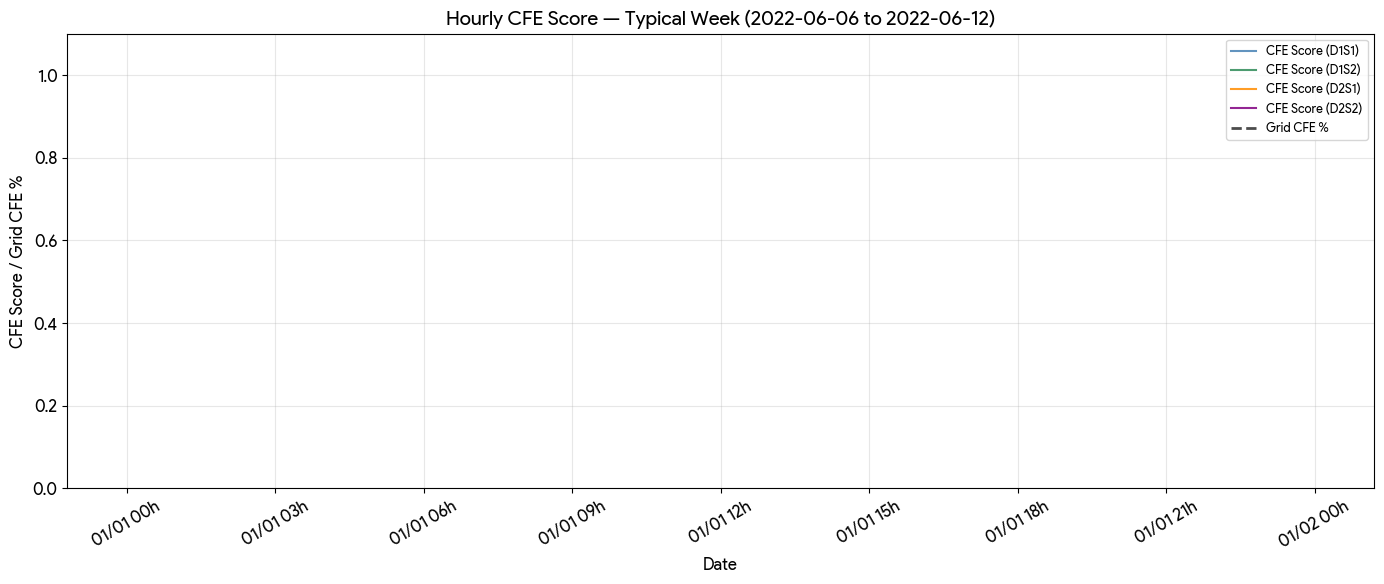

圖說：典型夏季週（2022/6/6–12）的逐時 CFE Score。黑虛線為電網 CFE%，彩色線為各情境。正午太陽能大發時，S1/S2 情境 score 飆升；夜間因無太陽能而大幅回落，顯示逐時匹配的挑戰。


In [66]:
# 典型一週 hourly CFE 時序
week_start, week_end = '2022-06-06', '2022-06-12'
week_mask = (year_idx >= week_start) & (year_idx <= week_end)
week_idx  = year_idx[week_mask]

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['steelblue', 'seagreen', 'darkorange', 'purple']
for (name, color) in zip(results.keys(), colors):
    ax.plot(week_idx, results[name]['hourly_scores'][week_idx],
            label=f'CFE Score ({name})', color=color, alpha=0.85, linewidth=1.5)

ax.plot(week_idx, grid_cfe[week_idx], 'k--', label='Grid CFE %', linewidth=2, alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('CFE Score / Grid CFE %')
ax.set_title('Hourly CFE Score — Typical Week (2022-06-06 to 2022-06-12)')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d %Hh'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cfe_typical_week.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("圖說：典型夏季週（2022/6/6–12）的逐時 CFE Score。黑虛線為電網 CFE%，彩色線為各情境。"
      "正午太陽能大發時，S1/S2 情境 score 飆升；夜間因無太陽能而大幅回落，顯示逐時匹配的挑戰。")

## 6. ML：天氣驅動因子分析

以線性迴歸（baseline）、Random Forest、XGBoost 三種模型，
預測下一小時的 Grid CFE %，分析哪些天氣與時間因子最能解釋電網「綠度」。

In [18]:
# Feature engineering
ml_df = df.copy()

# Lag 特徵（預測目標為當下 CFE%，但加入前一時刻資訊作為 feature）
ml_df['cfe_lag_1h']          = ml_df['grid_cfe_pct'].shift(1)
ml_df['cfe_lag_24h']         = ml_df['grid_cfe_pct'].shift(24)
ml_df['cfe_rolling_7d_mean'] = ml_df['grid_cfe_pct'].shift(1).rolling(24*7).mean()

# 確保氣象欄位無缺值
ml_df[WEATHER_COLS] = ml_df[WEATHER_COLS].ffill(limit=6).fillna(0)

# 移除 lag 造成的初始 NaN
ml_df = ml_df.dropna(subset=['cfe_lag_1h', 'cfe_lag_24h', 'cfe_rolling_7d_mean'])

FEATURES = ['hour', 'month', 'day_of_week', 'is_weekend',
            'Temperature', 'GloblRad', 'WS', 'Precp',
            'cfe_lag_1h', 'cfe_lag_24h', 'cfe_rolling_7d_mean']
TARGET = 'grid_cfe_pct'

print(f"ML dataset: {ml_df.shape}, features: {len(FEATURES)}")
ml_df[FEATURES + [TARGET]].describe().round(3)

ML dataset: (39242, 37), features: 11


,hour,month,day_of_week,is_weekend,Temperature,GloblRad,WS,Precp,cfe_lag_1h,cfe_lag_24h,cfe_rolling_7d_mean,grid_cfe_pct
count,39242.000,39242.000,39242.000,39242.000,39242.000,39242.000,39242.000,39242.000,39242.000,39242.000,39242.000,39242.000
mean,11.498,6.552,3.002,0.286,24.415,0.579,2.186,-0.652,0.172,0.172,0.172,0.172
std,6.925,3.294,2.002,0.452,5.771,0.924,1.286,6.071,0.062,0.062,0.027,0.062
min,0.000,1.000,0.000,0.000,-99.500,0.000,-99.500,-999.500,0.016,0.016,0.098,0.016
25%,5.000,4.000,1.000,0.000,20.000,0.000,1.200,0.000,0.129,0.129,0.153,0.129
50%,11.000,7.000,3.000,0.000,25.000,0.010,2.000,0.000,0.164,0.164,0.168,0.164
75%,18.000,9.000,5.000,1.000,28.700,0.820,3.000,0.000,0.204,0.204,0.192,0.204
max,23.000,12.000,6.000,1.000,39.000,4.300,11.100,90.000,0.584,0.584,0.271,0.584


In [19]:
# Train/test split：2020–2023 train，2024 test
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

train = ml_df[ml_df['year'] < 2024]
test  = ml_df[ml_df['year'] == 2024]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {len(X_train):,} rows  ({X_train.index.min().date()} – {X_train.index.max().date()})")
print(f"Test:  {len(X_test):,} rows  ({X_test.index.min().date()} – {X_test.index.max().date()})")

Train: 30,458 rows  (2020-01-08 – 2023-12-31)
Test:  8,784 rows  (2024-01-01 – 2024-12-31)


In [20]:
# 訓練三個模型並評估
models_def = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':           XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                      random_state=42, n_jobs=-1, verbosity=0),
}

metrics_dict = {}
preds_dict   = {}

for name, model in models_def.items():
    model.fit(X_train, y_train)
    y_pred = np.clip(model.predict(X_test), 0, 1)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    metrics_dict[name] = {'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R²': round(r2, 4)}
    preds_dict[name]   = y_pred
    print(f"{name:22s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")

print()
pd.DataFrame(metrics_dict).T

Linear Regression       RMSE=0.0223  MAE=0.0161  R²=0.9299
Random Forest           RMSE=0.0144  MAE=0.0092  R²=0.9708
XGBoost                 RMSE=0.0148  MAE=0.0095  R²=0.9692



,RMSE,MAE,R²
Linear Regression,0.0223,0.0161,0.9299
Random Forest,0.0144,0.0092,0.9708
XGBoost,0.0148,0.0095,0.9692


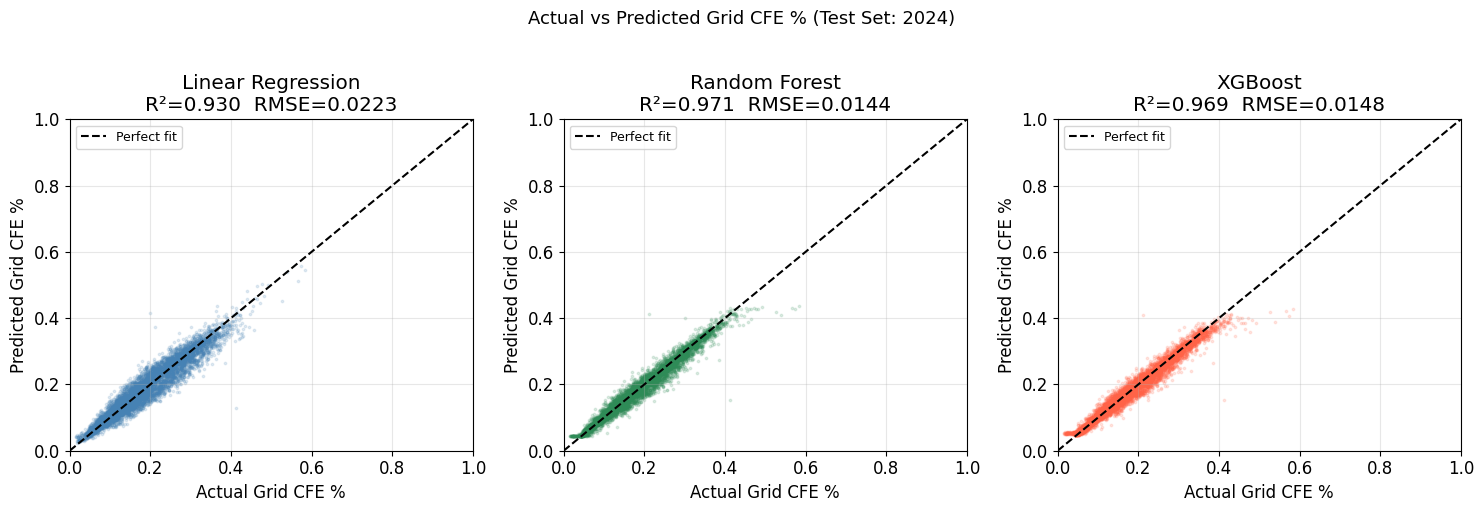

圖說：三種模型在 2024 年測試集的預測結果。XGBoost 與 Random Forest 的散點更接近對角線，線性迴歸因非線性關係而表現較差。


In [21]:
# Actual vs Predicted scatter（三模型並排）
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_colors = ['steelblue', 'seagreen', 'tomato']

for ax, (name, y_pred), color in zip(axes, preds_dict.items(), model_colors):
    ax.scatter(y_test, y_pred, alpha=0.15, s=3, color=color)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect fit')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Actual Grid CFE %')
    ax.set_ylabel('Predicted Grid CFE %')
    ax.set_title(f'{name}\nR²={metrics_dict[name]["R²"]:.3f}  RMSE={metrics_dict[name]["RMSE"]:.4f}')
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Actual vs Predicted Grid CFE % (Test Set: 2024)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'actual_vs_predicted.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("圖說：三種模型在 2024 年測試集的預測結果。XGBoost 與 Random Forest 的散點更接近對角線，"
      "線性迴歸因非線性關係而表現較差。")

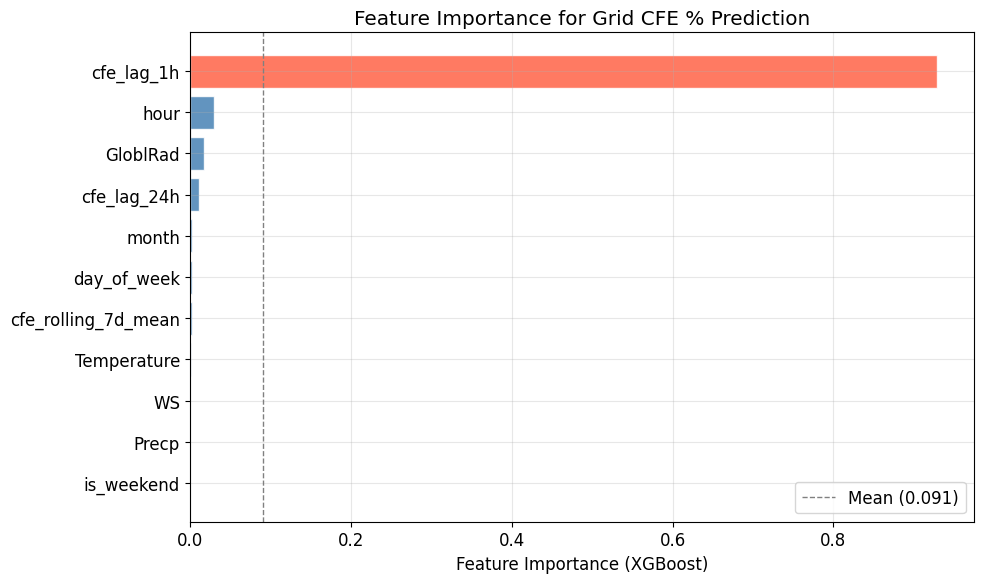

圖說：橫條圖顯示各特徵對預測 Grid CFE% 的重要性（紅色 = 高於均值）。Lag 特徵（前 1 小時、前 24 小時）通常占最高重要性，反映電網慣性；GloblRad（太陽輻射）是最重要的即時天氣驅動因子。


In [22]:
# Feature Importance（XGBoost）
xgb_model = models_def['XGBoost']
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()

mean_imp = importances.mean()
colors = ['tomato' if v > mean_imp else 'steelblue' for v in importances]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importances.index, importances.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(mean_imp, color='gray', linestyle='--', linewidth=1, label=f'Mean ({mean_imp:.3f})')
ax.set_xlabel('Feature Importance (XGBoost)')
ax.set_title('Feature Importance for Grid CFE % Prediction')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("圖說：橫條圖顯示各特徵對預測 Grid CFE% 的重要性（紅色 = 高於均值）。"
      "Lag 特徵（前 1 小時、前 24 小時）通常占最高重要性，反映電網慣性；"
      "GloblRad（太陽輻射）是最重要的即時天氣驅動因子。")

## 7. Discussion & Limitations

### 主要發現

1. **台灣電網 24/7 CFE 落差顯著**：即使年度 PPA 覆蓋率達 100%，逐時 CFE Score 仍約落在 50–70%，
   顯示純依靠年度憑證（RECs）的宣稱與實際逐時匹配存在實質落差。

2. **太陽能 PPA 夜間盲區**：純太陽能（S1）情境在夜間 CFE Score 幾乎全靠電網底色，
   落差最大；加入風力（S2）可改善夜間與冬季覆蓋。

3. **ML 模型發現**：Lag 特徵（前 1h、前 24h CFE%）重要性最高，
   天氣特徵中 GloblRad 是最關鍵的即時驅動因子，印證太陽能對台灣電網綠度的主導地位。

### 研究限制

| 限制 | 影響 |
|------|------|
| 排放係數精度（燃料別 vs 機組級） | 本研究使用 IPCC 2006 類別係數；機組級效率差異造成估算誤差 ±5–10% |
| 汽電共生（cogen）排除 | 約 5–8 GW 容量未計入，高估整體排放強度 |
| 抽蓄水力排除 | 充放電不對等可能略微低估尖峰排放 |
| 單一氣象站 | 僅代表北部地區；南台灣太陽能密集區氣象條件不同 |
| PPA 模擬假設 | 使用全台加總出力；實際 PPA 位置可能有輸電損耗與限電影響 |

### 與 TransitionZero (2025) 前瞻模型的對照

TransitionZero 預測台灣 2030 年再生能源占比可達 40–50%，屆時 Grid CFE% 將顯著提升。
本研究 2020–2024 基準線（Grid CFE% 約 20–30%）顯示目前仍有極大成長空間，
也突顯企業現階段採購 Solar+Wind 混合 PPA 的必要性。

## 8. AI 聲明

### 原創性聲明

本報告的研究問題設計、資料詮釋、分析發現及結論由本人獨立完成。
所有計算結果以台電公開資料及中央氣象署資料為基礎。

### AI 工具使用

| 工具 | 用途 |
|------|------|
| Claude (claude.ai) | 研究架構設計、方法論討論、報告結構建議 |
| Claude Code (claude-code CLI) | 程式碼生成、資料處理邏輯、視覺化規格設計 |

### AI 功能說明

- **程式碼生成**：Claude Code 協助生成 pandas/seaborn/sklearn/xgboost 程式碼框架
- **資料分析建議**：CFE 計算公式、燃料分類策略、ML feature 選擇
- **報告結構設計**：依課程規格規劃 8 節 Notebook 結構

### 代表性 Prompt 範例

```
User: 我有台電 10 分鐘發電資料（parquet），欄位包含 solar, solarU, wind, nuclear...
      請幫我設計 Grid CFE% 的計算邏輯，並說明哪些欄位應排除。

Claude: 依 IPCC 方法論，CFE 電源應包含...（以下為 AI 回覆）
```

### 前後比對：AI 輔助的影響

| 面向 | 初始構想 | AI 輔助後 |
|------|----------|-----------|
| 指標定義 | 只計算再生能源佔比 | 採用 Google 24/7 CFE Score 方法論 |
| 模擬情境 | 單一情境 | 4 種（D1/D2 × S1/S2）系統性比較 |
| ML 特徵 | 只用天氣變數 | 加入 lag 特徵、時間週期特徵 |
| 視覺化 | 折線圖為主 | Heatmap + Gap chart + Feature importance |